## Web Scraping and Natural Language Processing 

#### 1. State your question

What are the most frequent words in the novel Moby Dick and How often do they occur?

#### 2. Get your data

In [2]:
# store url
url = 'https://www.gutenberg.org/files/2701/2701-h/2701-h.htm'

In [3]:
# import requests
import requests

# make the request and check object type
r = requests.get(url)
print(type(r))

<class 'requests.models.Response'>


In [5]:
# extract HTML from Response object and print
html = r.text
print(html)

#### 3. Wrangle the data to answer the question 

In [7]:
# part 1: get the text from the HTML
# import BeautifulSoup from bs4
from bs4 import BeautifulSoup

# create a BeautifulSoup object from the HTML
soup = BeautifulSoup(html, 'html.parser')
print(type(soup))

<class 'bs4.BeautifulSoup'>


In [8]:
# get soup title
soup.title

<title>
      Moby Dick; Or the Whale, by Herman Melville
    </title>

In [9]:
# get soup title as string
soup.title.string

'\r\n      Moby Dick; Or the Whale, by Herman Melville\r\n    '

In [10]:
# get hyper links from soup and check out first several
soup.findAll('a')[:8]

[<a href="#link2H_4_0002"> ETYMOLOGY. </a>,
 <a href="#link2H_4_0003"> EXTRACTS (Supplied by a Sub-Sub-Librarian).
         </a>,
 <a href="#link2HCH0001"> CHAPTER 1. Loomings. </a>,
 <a href="#link2HCH0002"> CHAPTER 2. The Carpet-Bag. </a>,
 <a href="#link2HCH0003"> CHAPTER 3. The Spouter-Inn. </a>,
 <a href="#link2HCH0004"> CHAPTER 4. The Counterpane. </a>,
 <a href="#link2HCH0005"> CHAPTER 5. Breakfast. </a>,
 <a href="#link2HCH0006"> CHAPTER 6. The Street. </a>]

In [12]:
# get the text out of the soup and print it
text = soup.get_text()
print(text)

In [13]:
# part 2: extract words from the text with NLP
# step 1: tokenize
# import regex package
import re

# define showcase sentence
sentence = 'peter piper pick a peck of pickled peppers'

# define showcase regex
ps = 'p\w+'

# find all words in sentence that match the regex and print them
re.findall(ps, sentence)

['peter', 'piper', 'pick', 'peck', 'pickled', 'peppers']

In [14]:
# find all words and print them
re.findall('\w+', sentence)

['peter', 'piper', 'pick', 'a', 'peck', 'of', 'pickled', 'peppers']

In [15]:
# find all words in Moby Dick and print several
tokens = re.findall('\w+', text)
print(tokens[:8])

['Moby', 'Dick', 'Or', 'the', 'Whale', 'by', 'Herman', 'Melville']


In [17]:
# or tokenize with Natural language Toolkit: nltk
# import RegexpTokenizer from nltk.tokenize
from nltk.tokenize import RegexpTokenizer

# create tokenizer
tokenizer = RegexpTokenizer('\w+')

# create tokens
tokens = tokenizer.tokenize(text)
print(tokens[:8])

['Moby', 'Dick', 'Or', 'the', 'Whale', 'by', 'Herman', 'Melville']


In [18]:
# initialize new list
words = []

# loop through list tokens and make lower case
for word in tokens:
    words.append(word.lower())
    
# print several items from list as sanity check
print(words[:8])

['moby', 'dick', 'or', 'the', 'whale', 'by', 'herman', 'melville']


In [21]:
# step 2: remove stop words
# import nltk
import nltk

# install the stopwords
nltk.download('stopwords')

# get english stopwords and print some of them
sw = nltk.corpus.stopwords.words('english')
print(sw[:5])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


['i', 'me', 'my', 'myself', 'we']


In [22]:
# initialize new list
words_ns = []

# add to words_ns all words that are in words but not in sw
for word in words:
    if word not in sw:
        words_ns.append(word)
        
# print several list items as sanity check
print(words_ns[:5])

['moby', 'dick', 'whale', 'herman', 'melville']


#### 4. Answer the question

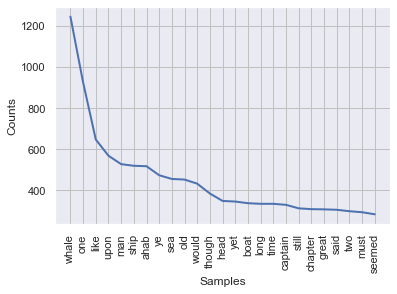

In [23]:
# import datavis libraries
import matplotlib.pyplot as plt
import seaborn as sns

# figures inline and set visualisation style
%matplotlib inline
sns.set()

# create freq dist and plot
freqdist1 = nltk.FreqDist(words_ns)
freqdist1.plot(25)

#### 5. Present the solution :)

### Bonus material

In [24]:
# define function doing all of this in a single place
def plot_word_freq(url): # takes url and plots a word frequency distribution
    # make the request and check object
    r = requests.get(url)
    # extract HTML from Response object
    html = r.text
    # create a BeautifulSoup object from HTML
    soup = BeautifulSoup(html, 'html.parser')
    # get the text out of the soup and print it
    text = soup.get_text()
    # create tokenizer
    tokenizer = RegexpTokenizer('\w+')
    # create tokens
    tokens = tokenizer.tokenize(text)
    # initialize new list
    words = []
    # loop through list tokens and make lower case
    for word in tokens:
        words.append(word.lower())
    # get english stopwords
    sw = nltk.corpus.stopwords.words('english')
    # initialize new list
    words_ns = []
    # add to words_ns all words that are in words but not in sw
    for word in words:
        if word not in sw:
            words_ns.append(word)
    # create freq dist and plot
    freqdist1 = nltk.FreqDist(words_ns)
    freqdist1.plot(25)

In [25]:
# use the  function to plot word frequency distributions from other texts

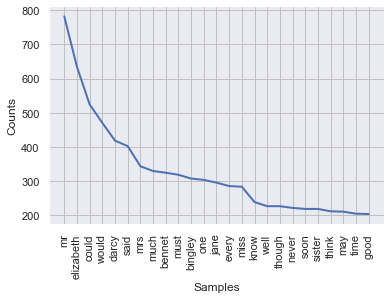

In [26]:
# Pride and Prejudice
fig1 = plot_word_freq('https://www.gutenberg.org/files/42671/42671-h/42671-h.htm')

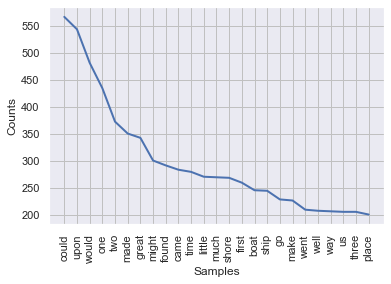

In [27]:
# Robinson Crusoe
fig2 = plot_word_freq('https://www.gutenberg.org/files/521/521-h/521-h.htm')

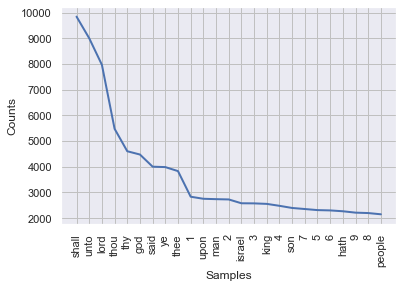

In [28]:
# The King James Bible
fig3 = plot_word_freq('https://www.gutenberg.org/files/10/10-h/10-h.htm')